# Autoregressive Rollout Evaluation

Evaluates the trained conditional flow-matching model by rolling out predictions autoregressively:

$$\hat{x}_{t+1} = \text{ODE}(z_0 \sim \mathcal{N}(0,I),\; x_t) \quad \rightarrow \quad \hat{x}_{t+2} = \text{ODE}(z_0 \sim \mathcal{N}(0,I),\; \hat{x}_{t+1}) \quad \rightarrow \quad \cdots$$

**Metrics:**
- **RMSE** — Root Mean Squared Error of the ensemble mean vs. ground truth
- **CRPS** — Continuous Ranked Probability Score (probabilistic skill of marginal distributions)
- **SSR** — Spread/Skill Ratio (calibration: should be ~1 for a well-calibrated ensemble)

## 1. Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add SQG folder to path so we can import SongUNet — same as in training notebook
SQG_DIR = Path('SQG')
sys.path.insert(0, str(SQG_DIR))

from diffusion_networks import SongUNet
from natsort import natsorted
from sampler import Sampler

## 2. Config

In [3]:
# ── paths ─────────────────────────────────────────────────────────────────
DATA_DIR = Path('../data/') 
MODEL_PATH = Path('../models/results/best_model_conditional.pth')

# ── data ──────────────────────────────────────────────────────────────────
DATA_STD   = 2660.0
TRAIN_FRAC = 0.8          # must match training split

# ── model (must match training config exactly) ────────────────────────────
IMG_CHANNELS   = 2
IMG_RESOLUTION = 64
FILTERS        = 32
LABEL_DROPOUT  = 0.1

# ── evaluation ────────────────────────────────────────────────────────────
N_ENSEMBLE    = 10    # number of ensemble members per rollout
ROLLOUT_STEPS = 20   # how many autoregressive steps to evaluate
ODE_STEPS     = 100  # Euler steps inside each ODE solve
N_INIT        = 20   # number of different starting points to average metrics over

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Model path exists: {MODEL_PATH.exists()}')

Device: cuda
Model path exists: True


## 3. Load Data (val split only)

In [4]:
# load and split files by trajectory, not by time
files = natsorted(DATA_DIR.glob('sqg_N64_1hrly_*.npy'))
assert len(files) > 0, f"No files found in {DATA_DIR}"

cut        = int(len(files) * TRAIN_FRAC)
val_files  = files[cut:]
# should we use SQGPairDataset? it's for pair tho

# load all val trajectories
val_trajs = []
for f in val_files:
    arr = torch.tensor(np.load(f).astype(np.float32) / DATA_STD)  # (T, C, H, W)
    val_trajs.append(arr)

T_per_traj = val_trajs[0].shape[0]
print(f'Total trajectories: {len(files)},  train: {cut},  val: {len(val_files)}')
print(f'Timesteps per trajectory: {T_per_traj},  val data shape: {val_trajs[0].shape}')

# pick N_INIT (traj_idx, t) starting points from val trajectories
# ensure t + ROLLOUT_STEPS < T so we have enough ground truth
max_t      = T_per_traj - ROLLOUT_STEPS - 1
assert max_t > 0, 'Trajectory too short for requested rollout length'

rng          = np.random.default_rng(42)
traj_indices = rng.integers(0, len(val_trajs), size=N_INIT)
time_indices = rng.integers(0, max_t,          size=N_INIT)
init_points  = list(zip(traj_indices.tolist(), time_indices.tolist()))

print(f'\nSampled {N_INIT} init points: (traj_idx, t_start)')
for ti, t in init_points:
    print(f'  traj={ti}, t={t}')

Total trajectories: 100,  train: 80,  val: 20
Timesteps per trajectory: 101,  val data shape: torch.Size([101, 2, 64, 64])

Sampled 20 init points: (traj_idx, t_start)
  traj=1, t=40
  traj=15, t=29
  traj=13, t=14
  traj=8, t=74
  traj=8, t=62
  traj=17, t=51
  traj=1, t=32
  traj=13, t=65
  traj=4, t=43
  traj=1, t=35
  traj=10, t=36
  traj=19, t=18
  traj=14, t=7
  traj=15, t=44
  traj=14, t=71
  traj=15, t=5
  traj=10, t=68
  traj=2, t=66
  traj=16, t=22
  traj=9, t=50


## 4. Load Model

In [5]:
model = SongUNet(
    img_resolution     = IMG_RESOLUTION,
    in_channels        = IMG_CHANNELS * 2,
    out_channels       = IMG_CHANNELS,
    embedding_type     = 'fourier',
    encoder_type       = 'residual',
    decoder_type       = 'standard',
    channel_mult_noise = 2,
    resample_filter    = [1, 3, 3, 1],
    model_channels     = FILTERS,
    channel_mult       = [2, 2, 2],
    attn_resolutions   = [32],
    label_dropout      = LABEL_DROPOUT,
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Model loaded successfully')

Model loaded successfully


/tmp/ipykernel_50147/3794367460.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


## 5. Sampling Function

In [6]:
# change the sample function
# use function in the sampler.py instead
# it might be related with steps

@torch.no_grad()
def sample_one_step(model, x_t, steps=500):
    """
    One conditional flow ODE solve: noise -> x_{t+1}.

    Args:
        model : trained SongUNet
        x_t   : conditioning state, shape (B, C, H, W)
        steps : Euler integration steps

    Returns:
        x_t1_pred, shape (B, C, H, W)
    """
    B  = x_t.shape[0]
    dt = 1.0 / steps
    z  = torch.randn_like(x_t)                         # fresh noise each call
    for i in range(steps):
        s = torch.full((B,), i * dt, device=x_t.device)
        b = model(z, s, class_labels=x_t)              # predicted velocity
        z = z + b * dt                                 # Euler step
    return z


@torch.no_grad()
def autoregressive_ensemble_rollout(model, x0, rollout_steps, n_ensemble, ode_steps=500):
    """
    Roll out an ensemble of trajectories autoregressively.

    Args:
        model         : trained SongUNet
        x0            : initial condition, shape (C, H, W)
        rollout_steps : number of autoregressive steps
        n_ensemble    : number of ensemble members
        ode_steps     : Euler steps per ODE solve

    Returns:
        preds : np.ndarray, shape (rollout_steps, n_ensemble, C, H, W)
                All values are in normalised space (same as input data).
    """
    # broadcast x0 across ensemble members: (n_ensemble, C, H, W)
    x_current = x0.unsqueeze(0).expand(n_ensemble, -1, -1, -1).clone().to(device)

    preds = []
    for _ in range(rollout_steps):
        x_next = sample_one_step(model, x_current, steps=ode_steps)  # (n_ens, C, H, W)
        preds.append(x_next.cpu().numpy())
        x_current = x_next                                            # feed prediction forward

    return np.stack(preds, axis=0)   # (rollout_steps, n_ensemble, C, H, W)

## 6. Metric Definitions

All metrics are computed **per lead time**, averaged over spatial pixels, channels, and init points.

- **RMSE**: $\sqrt{\mathbb{E}[(\bar{x}_{\text{pred}} - x_{\text{truth}})^2]}$ where $\bar{x}_{\text{pred}}$ is the ensemble mean
- **CRPS**: $\mathbb{E}_{m}[|x^m - x_{\text{truth}}|] - \frac{1}{2}\mathbb{E}_{m,m'}[|x^m - x^{m'}|]$ (energy form)
- **SSR**: $\frac{\text{ensemble spread}}{\text{RMSE}}$ — well-calibrated when $\approx 1$

In [7]:
def compute_rmse(preds_mean, truth):
    se = (preds_mean - truth) ** 2
    return np.sqrt(se.mean(axis=(1, 2, 3)))


def compute_crps(preds, truth):
    """
    Vectorised energy-form CRPS.

    Args:
        preds : (rollout_steps, n_ensemble, C, H, W)
        truth : (rollout_steps, C, H, W)
    Returns:
        crps  : (rollout_steps,)
    """
    # E[|X - y|]
    mae = np.abs(preds - truth[:, np.newaxis]).mean(axis=1)   # (steps, C, H, W)

    # E[|X - X'|] via: 2/n^2 * sum_i sum_j>i |x_i - x_j|
    # equivalent closed form: 2 * std * sqrt(n/(n-1)) * ... but simpler:
    # E[|X-X'|] = 2 * mean_i[ |x_i - mean| ] is NOT correct;
    # correct O(n) form: sort members, use CDF trick
    n   = preds.shape[1]
    s   = np.sort(preds, axis=1)                              # (steps, n, C, H, W)
    w   = 2 * np.arange(1, n + 1) - n - 1                    # (n,)
    w   = w.reshape(1, n, 1, 1, 1)
    spread = (w * s).sum(axis=1) / (n * (n - 1))             # (steps, C, H, W)

    crps_field = mae - spread
    return crps_field.mean(axis=(1, 2, 3))


def compute_ssr(preds, rmse):
    spread = preds.std(axis=1).mean(axis=(1, 2, 3))
    return spread / (rmse + 1e-8)

## 7. Run Evaluation

In [8]:
all_rmse = []
all_crps = []
all_ssr  = []

for ti, t in tqdm(init_points, desc='Evaluating init points'):
    x0    = val_trajs[ti][t]                                    # (C, H, W)
    truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()  # (steps, C, H, W)

    # ensemble rollout
    preds = autoregressive_ensemble_rollout(
        model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS
    )   # (steps, n_ens, C, H, W)

    preds_mean = preds.mean(axis=1)                                # (steps, C, H, W)

    rmse = compute_rmse(preds_mean, truth)                         # (steps,)
    crps = compute_crps(preds, truth)                              # (steps,)
    ssr  = compute_ssr(preds, rmse)                                # (steps,)

    all_rmse.append(rmse)
    all_crps.append(crps)
    all_ssr.append(ssr)

# average over init points
mean_rmse = np.stack(all_rmse).mean(axis=0)   # (steps,)
mean_crps = np.stack(all_crps).mean(axis=0)
mean_ssr  = np.stack(all_ssr).mean(axis=0)

lead_times = np.arange(1, ROLLOUT_STEPS + 1)

print(f'\nResults averaged over {N_INIT} init points:')
print(f'{"Lead":>5}  {"RMSE":>8}  {"CRPS":>8}  {"SSR":>8}')
for t, r, c, s in zip(lead_times, mean_rmse, mean_crps, mean_ssr):
    print(f'{t:5d}  {r:8.4f}  {c:8.4f}  {s:8.4f}')

Evaluating init points:   0%|          | 0/20 [00:11<?, ?it/s]


KeyboardInterrupt: 

## 8. Plot Metrics vs Lead Time

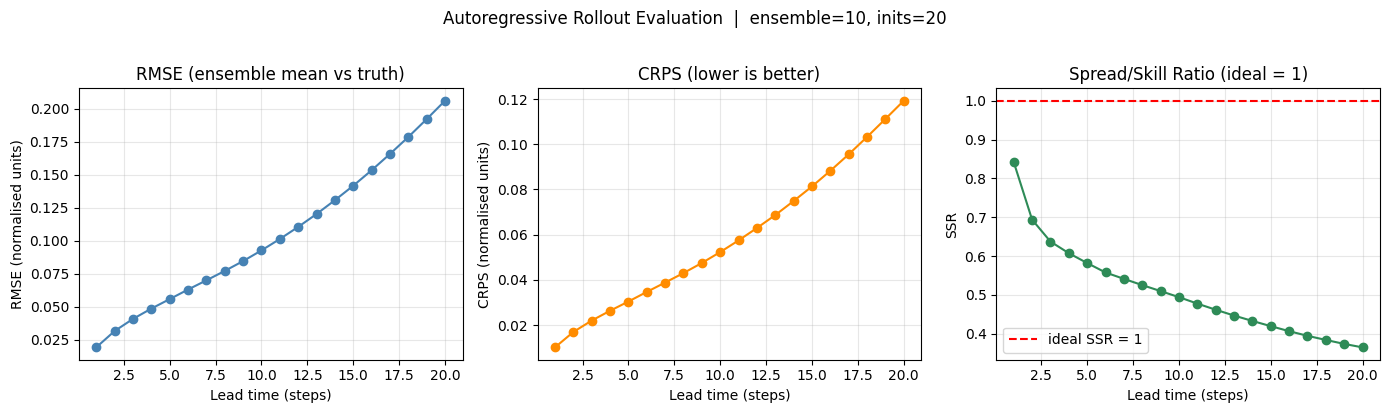

Plot saved to results/eval_metrics.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(lead_times, mean_rmse, marker='o', color='steelblue')
axes[0].set_title('RMSE (ensemble mean vs truth)')
axes[0].set_xlabel('Lead time (steps)')
axes[0].set_ylabel('RMSE (normalised units)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lead_times, mean_crps, marker='o', color='darkorange')
axes[1].set_title('CRPS (lower is better)')
axes[1].set_xlabel('Lead time (steps)')
axes[1].set_ylabel('CRPS (normalised units)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lead_times, mean_ssr, marker='o', color='seagreen')
axes[2].axhline(1.0, color='red', linestyle='--', label='ideal SSR = 1')
axes[2].set_title('Spread/Skill Ratio (ideal = 1)')
axes[2].set_xlabel('Lead time (steps)')
axes[2].set_ylabel('SSR')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Autoregressive Rollout Evaluation  |  ensemble={N_ENSEMBLE}, inits={N_INIT}', y=1.02)
plt.tight_layout()
plt.show()
print('Plot saved to results/eval_metrics.png')

## 9. Visual Sanity Check — One Rollout Trajectory

Plots the ground truth vs ensemble mean for a single init point at selected lead times.

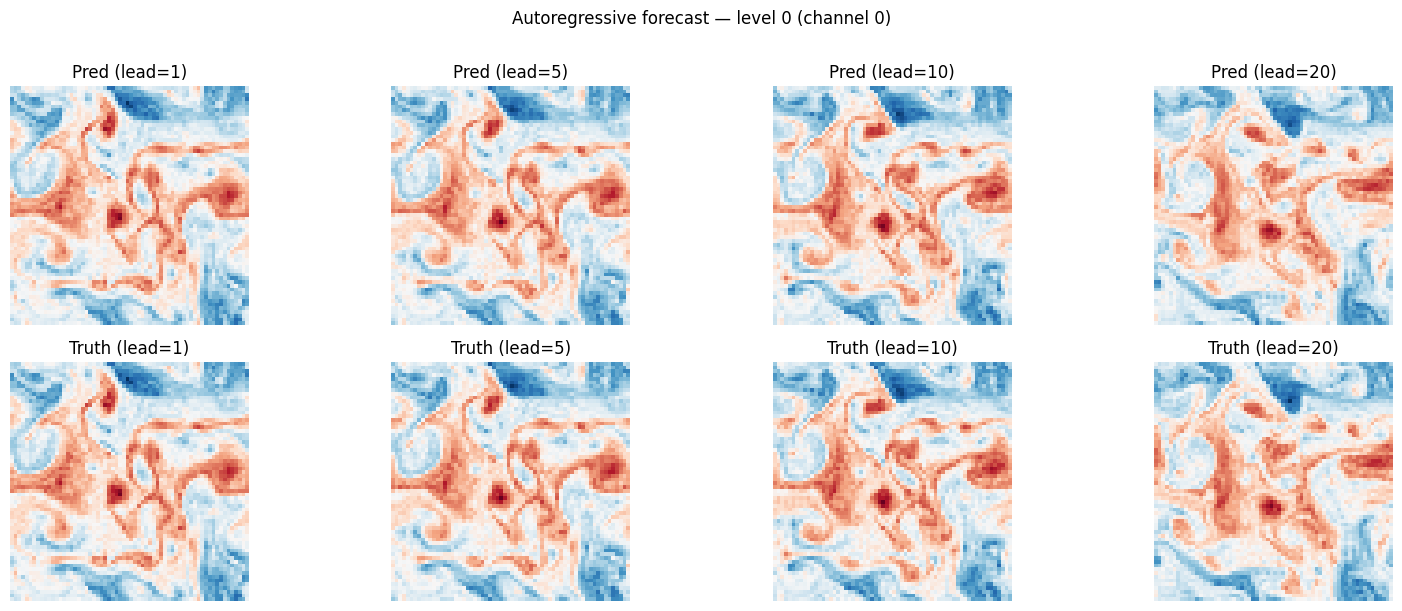

Trajectory plot saved to results/eval_trajectory.png


In [23]:
# use the first init point
ti, t = init_points[0]
x0    = val_trajs[ti][t]
truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()


preds = autoregressive_ensemble_rollout(model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS)
preds_mean = preds.mean(axis=1)   # (steps, C, H, W)

# show steps 1, 5, 10, 20 (or fewer if ROLLOUT_STEPS < 20)
show_steps = [s for s in [1, 5, 10, 20] if s <= ROLLOUT_STEPS]
n_show = len(show_steps)

fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6))
for col, step in enumerate(show_steps):
    vmax = np.abs(truth[step - 1, 0]).max()
    axes[0, col].imshow(preds_mean[step - 1, 0], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, col].set_title(f'Pred (lead={step})')
    axes[0, col].axis('off')
    axes[1, col].imshow(truth[step - 1, 0],      cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, col].set_title(f'Truth (lead={step})')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Ensemble Mean', fontsize=10)
axes[1, 0].set_ylabel('Ground Truth',  fontsize=10)

plt.suptitle('Autoregressive forecast — level 0 (channel 0)', y=1.01)
plt.tight_layout()
plt.show()
print('Trajectory plot saved to results/eval_trajectory.png')